# Local longevity analysis

This notebook reads every spreadsheet registered in data/metadata.csv, calculates period life table indicators, and writes charts to outputs/figures.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config.settings import K_MAX
from src.data.loaders import load_life_tables_from_metadata, load_metadata
from src.analysis.hazard import add_survival_hazard
from src.analysis.indicators import (
    age_band_hazard_contributions,
    build_indicators,
    build_milestone_long,
    conditional_survival_probabilities,
    sex_indicator_gaps,
)
from src.visualization.plots import (
    plot_age_band_hazard_contributions,
    plot_benchmark_hazard_gap_vs_chile,
    plot_conditional_survival,
    plot_hazard_curves,
    plot_sex_hazard_gap_by_region,
    plot_sex_indicator_gaps,
    plot_survival_curves,
)


## Registered spreadsheets

In [2]:
metadata = load_metadata()
metadata

,filename,country,year,sex,label
0,female_life_table_northeast_brazil_2025.xlsx,Northeast Brazil,2025,Female,Northeast Brazil - Female
1,female_life_table_chile_2023.xlsx,Chile,2023,Female,Chile - Female
2,male_life_table_northeast_brazil_2025.xlsx,Northeast Brazil,2025,Male,Northeast Brazil - Male
3,male_life_table_chile_2023.xlsx,Chile,2023,Male,Chile - Male
4,female_life_table_north_brazil_2025.xlsx,North Brazil,2025,Female,North Brazil - Female
5,male_life_table_north_brazil_2025.xlsx,North Brazil,2025,Male,North Brazil - Male


## Indicators

In [3]:
raw = load_life_tables_from_metadata()
life_tables = add_survival_hazard(raw)
indicators = build_indicators(life_tables, k_max=K_MAX)
milestones = build_milestone_long(life_tables, k_max=K_MAX)

indicators

,country,year,age_min,age_max,H_max,H_60,H_70,H_80,H_90,H_100,...,modal_age,median_age,x_H1,x_H2,x_H3,x_H4,x_H5,x_H6,x_H7,x_H8
0,Chile - Female,2023,0.0,90.0,1.071908,0.064922,0.148925,0.375851,1.071908,NaN,...,87.5,85.688245,89.159684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Chile - Male,2023,0.0,90.0,1.367944,0.110327,0.239530,0.548971,1.367944,NaN,...,82.5,82.361327,86.202682,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,North Brazil - Female,2025,0.0,90.0,1.374586,0.105360,0.210844,0.483792,1.374586,NaN,...,87.5,83.492009,86.745260,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,North Brazil - Male,2025,0.0,90.0,1.853139,0.208960,0.380264,0.772962,1.853139,NaN,...,87.5,78.496718,82.902316,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Northeast Brazil - Female,2025,0.0,90.0,1.330084,0.104435,0.208108,0.467868,1.330084,NaN,...,87.5,83.880125,87.059204,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Northeast Brazil - Male,2025,0.0,90.0,1.845215,0.226562,0.405321,0.785781,1.845215,NaN,...,87.5,78.174673,82.827433,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Overview

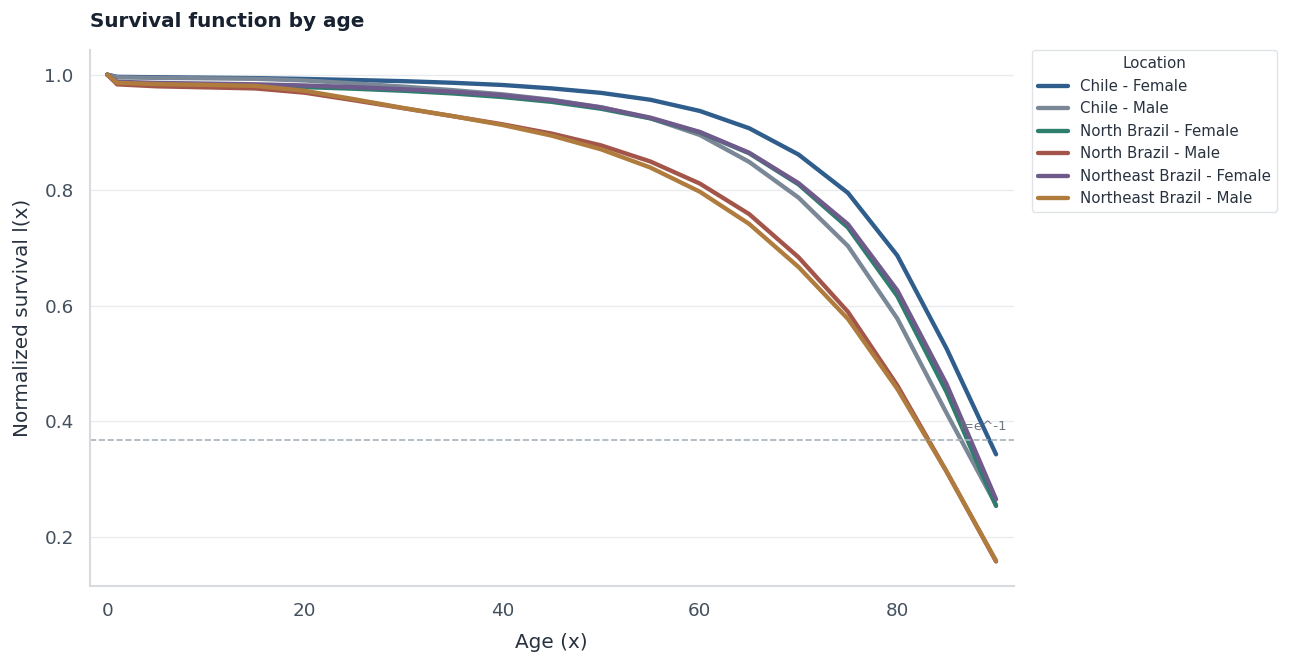

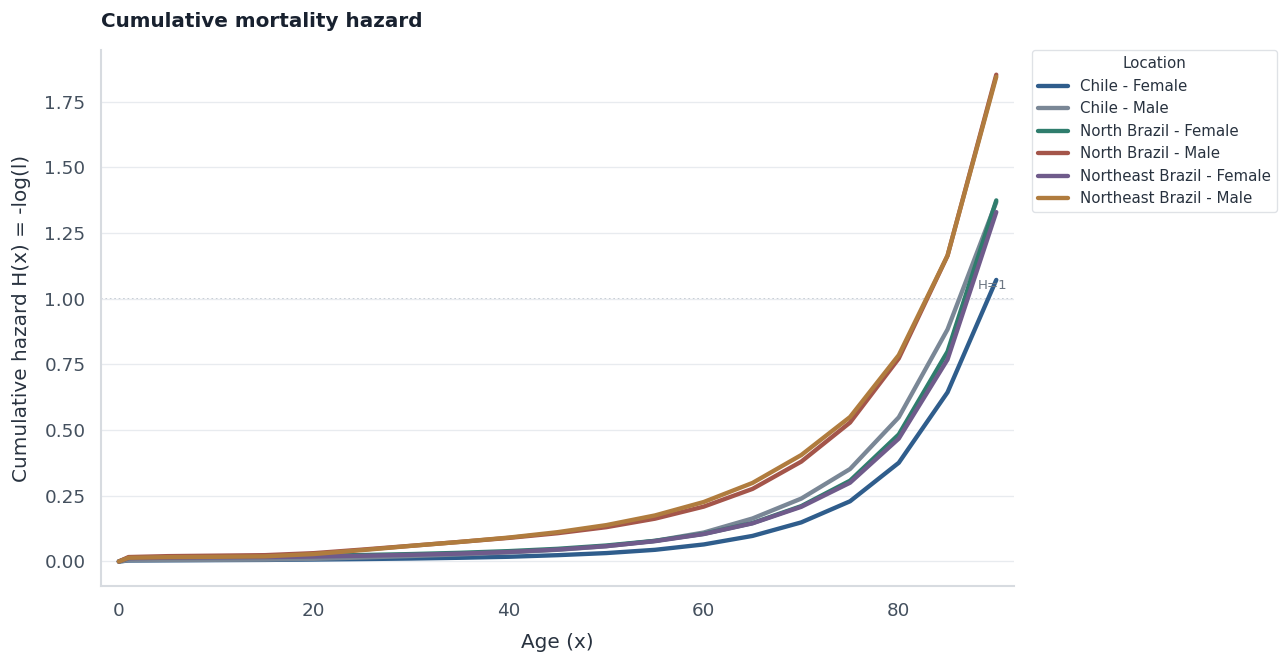

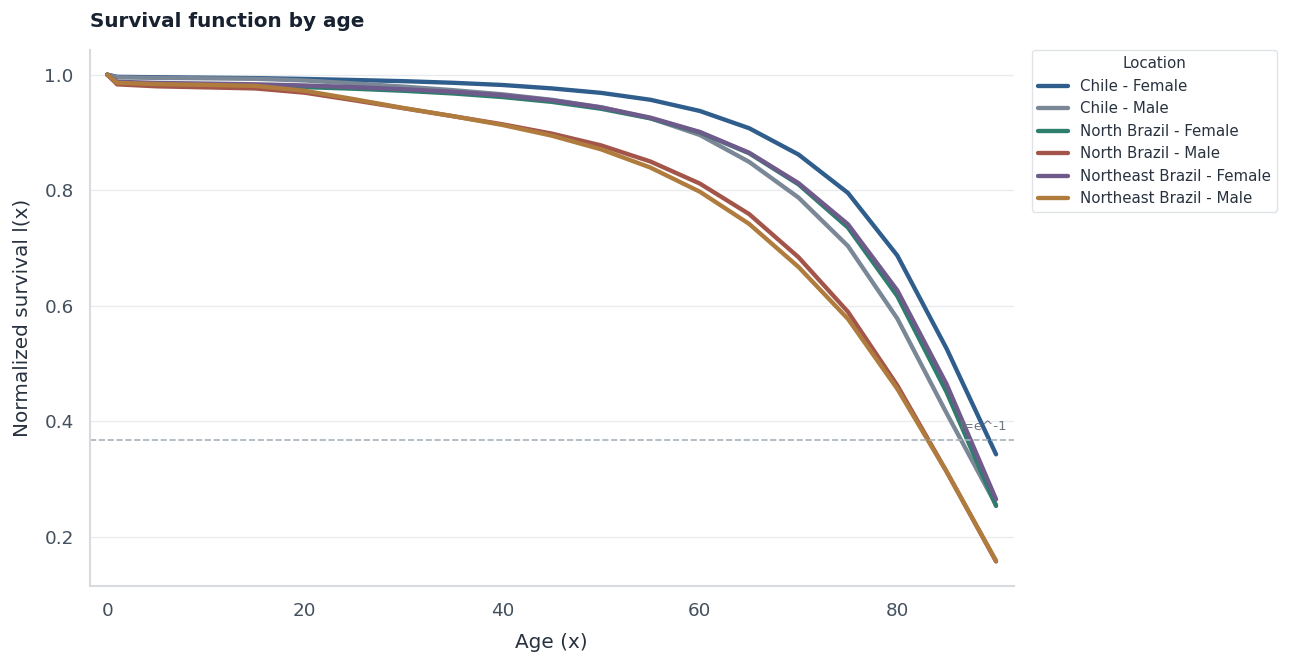

In [4]:
plot_hazard_curves(life_tables)
plot_survival_curves(life_tables)


## Sex differences in Brazilian regions

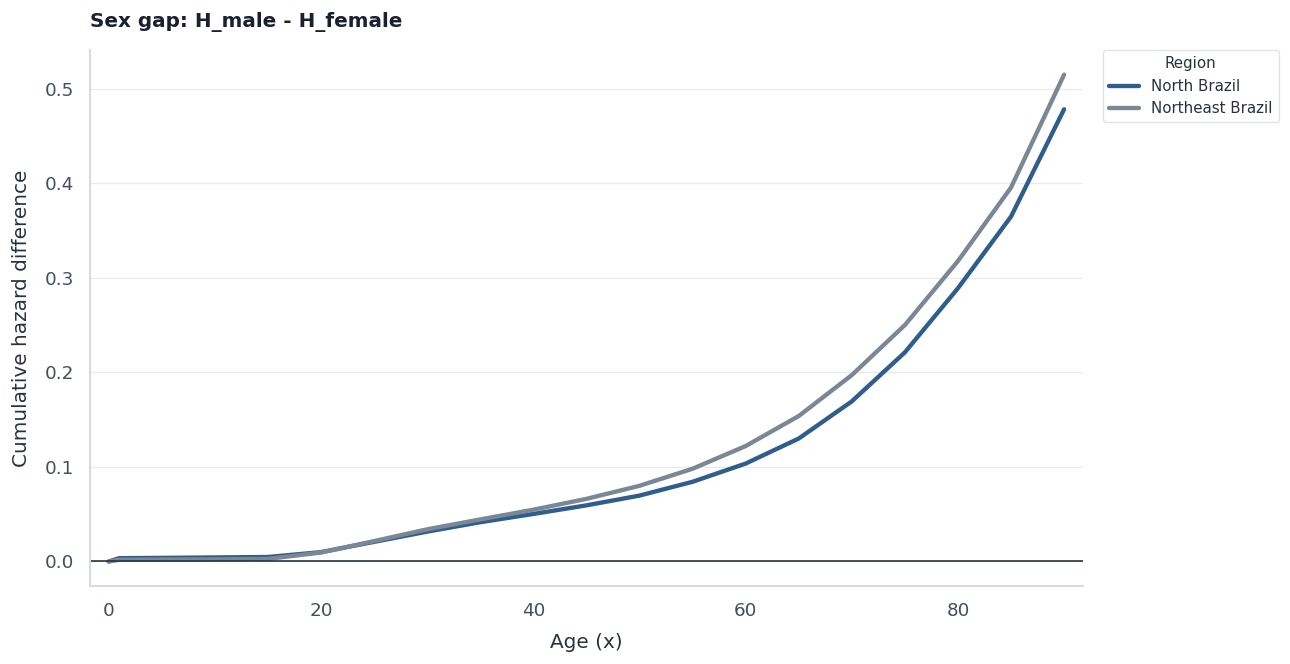

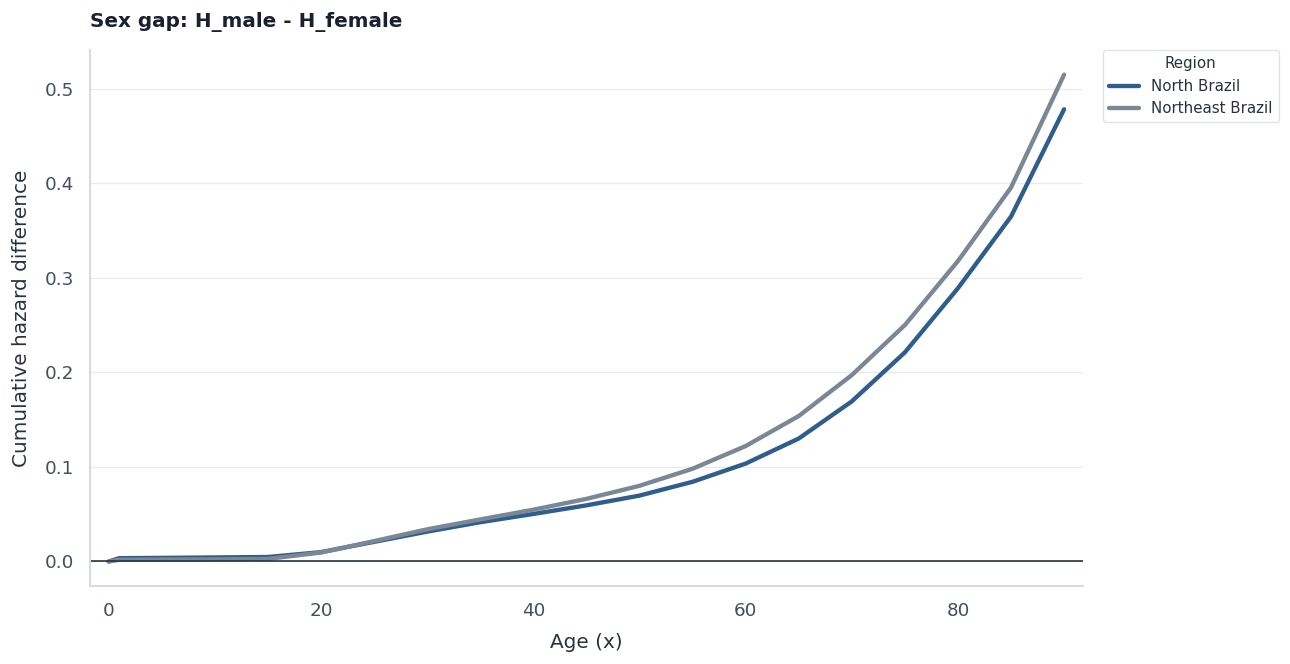

In [5]:
plot_sex_hazard_gap_by_region(life_tables)

## Chile as an external benchmark

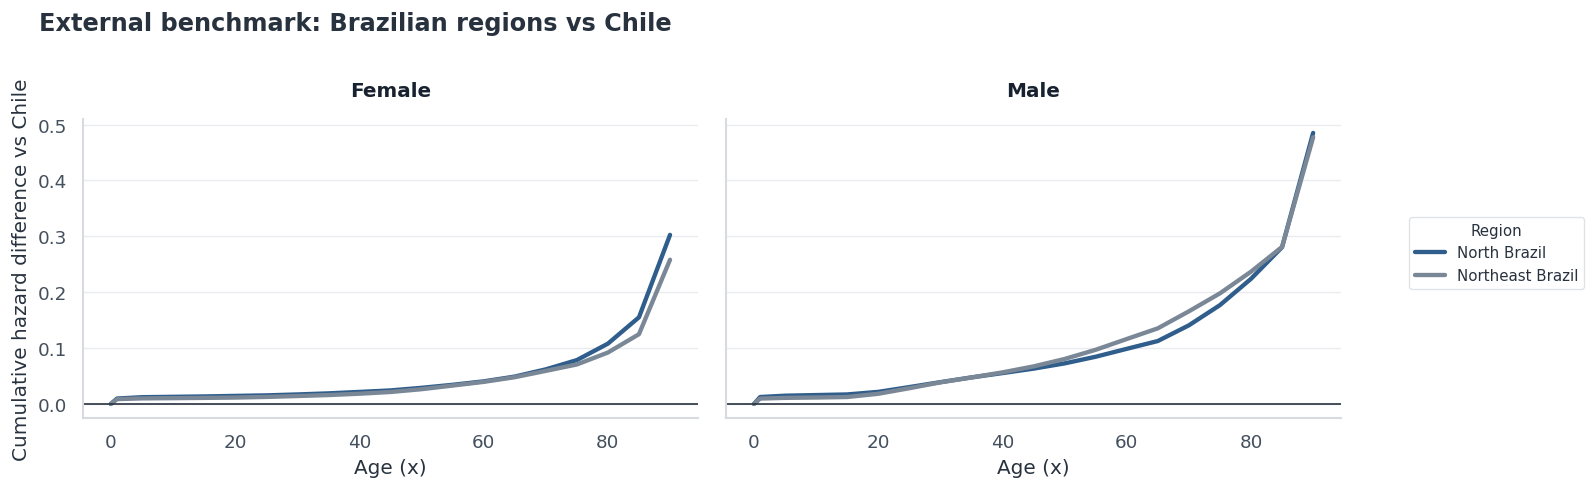

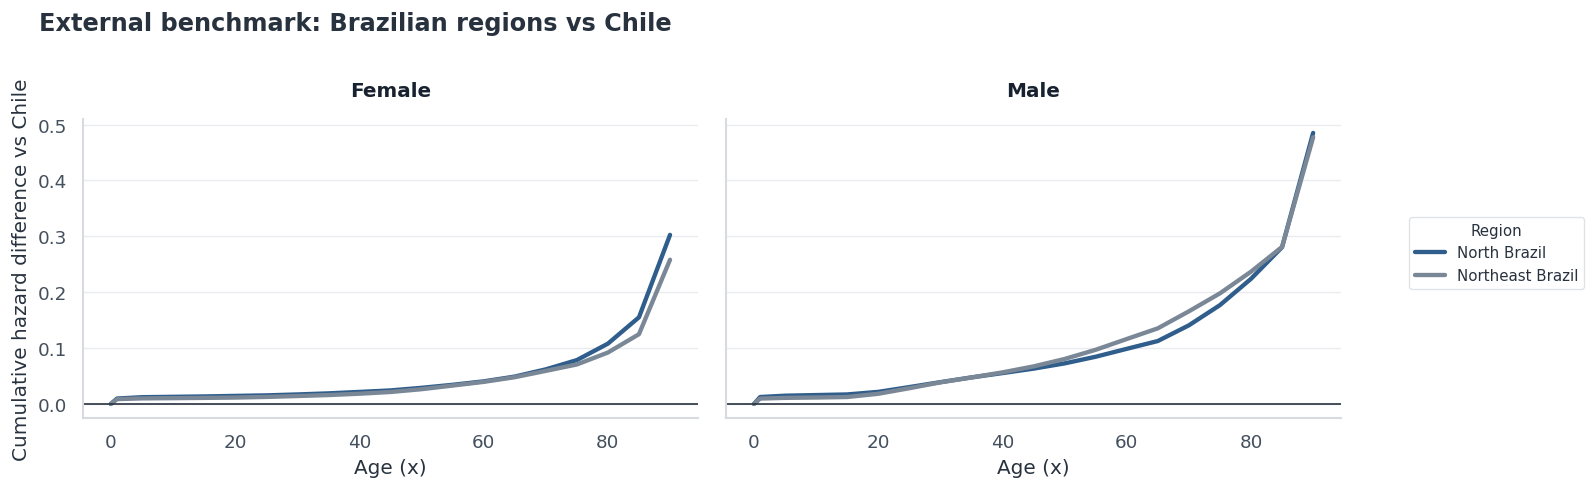

In [6]:
plot_benchmark_hazard_gap_vs_chile(life_tables)

## Additional analyses

Conditional survival probabilities, hazard decomposition by age band, and female-male gaps in summary indicators.


In [7]:
conditional_survival = conditional_survival_probabilities(life_tables)
age_band_contributions = age_band_hazard_contributions(life_tables)
sex_gaps = sex_indicator_gaps(indicators)

conditional_survival


,country,year,start_age,end_age,transition,conditional_survival
0,Chile - Female,2023,60,80,60-80,0.732766
1,Chile - Female,2023,60,90,60-90,0.365319
2,Chile - Female,2023,80,90,80-90,0.498547
3,Chile - Female,2023,90,100,90-100,NaN
4,Chile - Male,2023,60,80,60-80,0.644911
5,Chile - Male,2023,60,90,60-90,0.284331
6,Chile - Male,2023,80,90,80-90,0.440884
7,Chile - Male,2023,90,100,90-100,NaN
8,North Brazil - Female,2025,60,80,60-80,0.684934
9,North Brazil - Female,2025,60,90,60-90,0.281049


In [8]:
age_band_contributions


,country,year,start_age,end_age,age_band,hazard_increment,share_of_observed_increment
0,Chile - Female,2023,0,40,0-40,0.018000,0.047890
1,Chile - Female,2023,40,60,40-60,0.046923,0.124844
2,Chile - Female,2023,60,80,60-80,0.310928,0.827266
3,Chile - Female,2023,80,100,80-100,NaN,NaN
4,Chile - Female,2023,100,120,100-120,NaN,NaN
5,Chile - Male,2023,0,40,0-40,0.034578,0.062986
6,Chile - Male,2023,40,60,40-60,0.075750,0.137985
7,Chile - Male,2023,60,80,60-80,0.438643,0.799029
8,Chile - Male,2023,80,100,80-100,NaN,NaN
9,Chile - Male,2023,100,120,100-120,NaN,NaN


In [9]:
sex_gaps


,region,year,indicator,female_value,male_value,gap_female_minus_male
0,Chile,2023,H_80,0.375851,0.548971,-0.173120
1,Chile,2023,H_90,1.071908,1.367944,-0.296036
2,Chile,2023,x_H1,89.159684,86.202682,2.957001
3,Chile,2023,e0_approx,81.042863,77.750274,3.292589
4,Chile,2023,median_age,85.688245,82.361327,3.326918
5,Chile,2023,modal_age,87.500000,82.500000,5.000000
6,North Brazil,2025,H_80,0.483792,0.772962,-0.289170
7,North Brazil,2025,H_90,1.374586,1.853139,-0.478553
8,North Brazil,2025,x_H1,86.745260,82.902316,3.842944
9,North Brazil,2025,e0_approx,78.080294,72.280232,5.800062


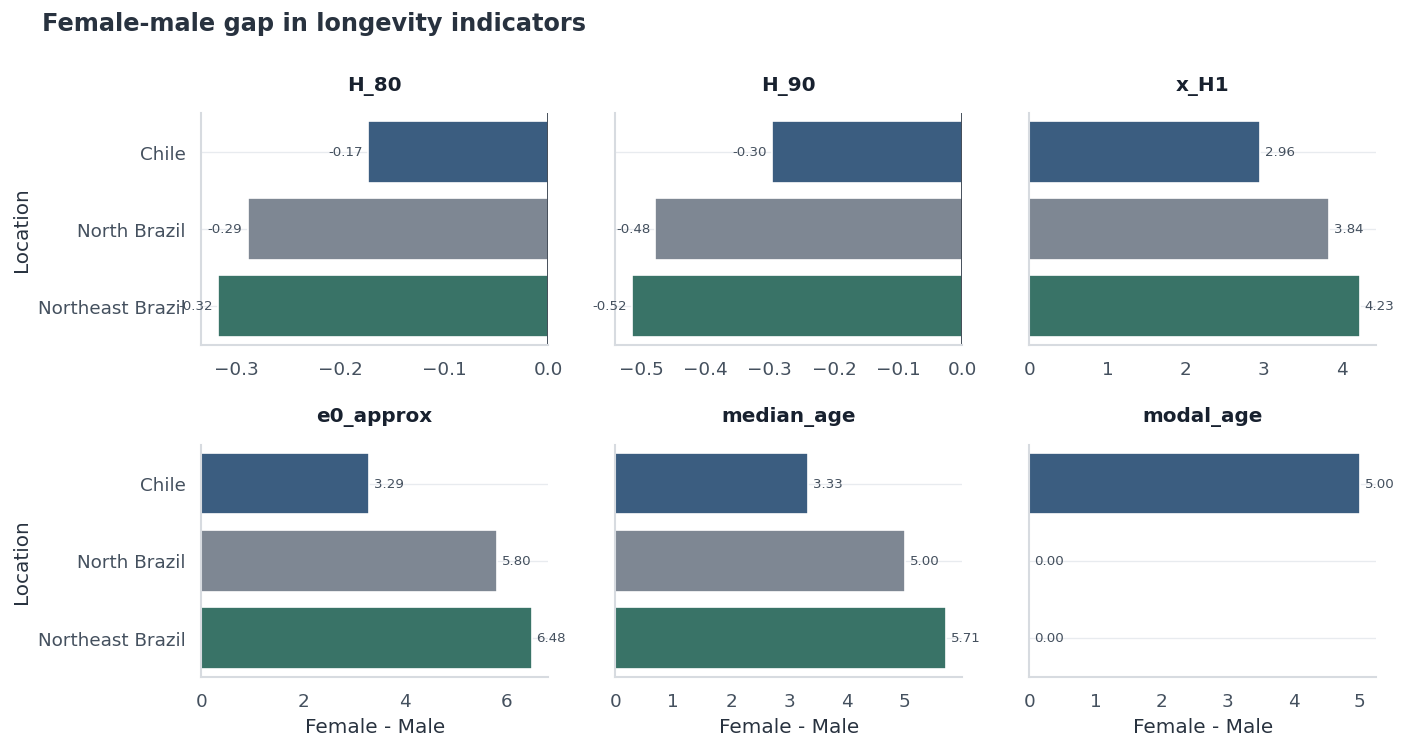

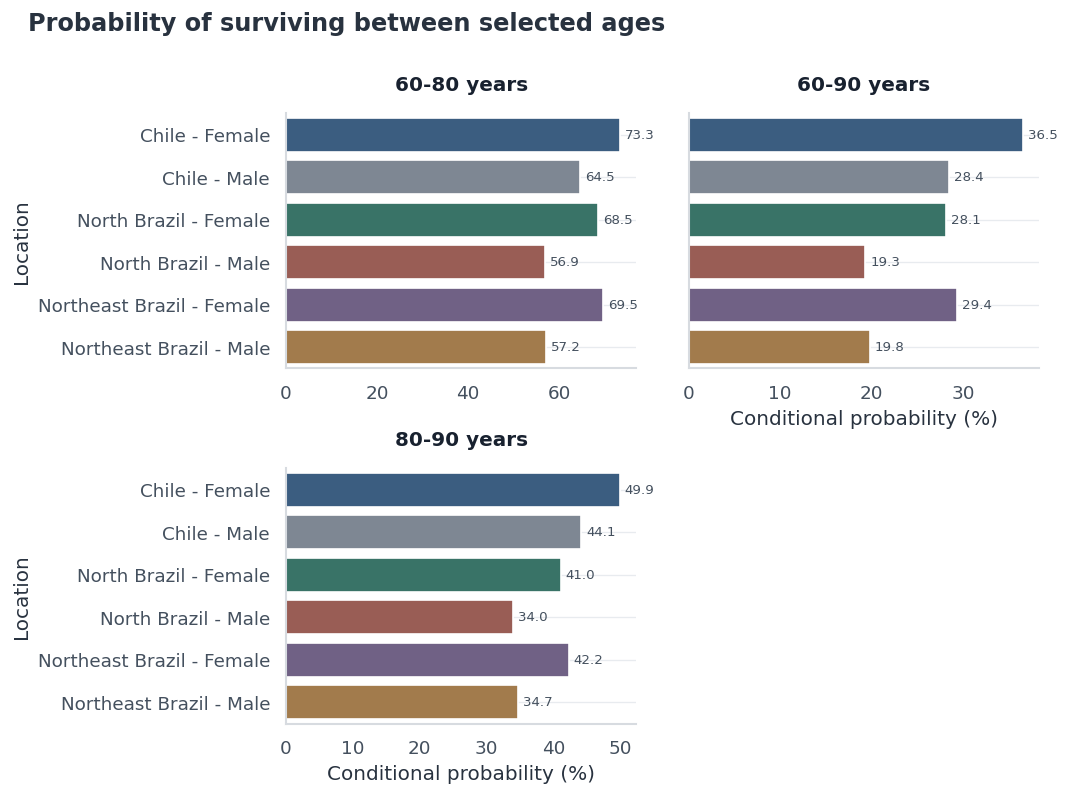

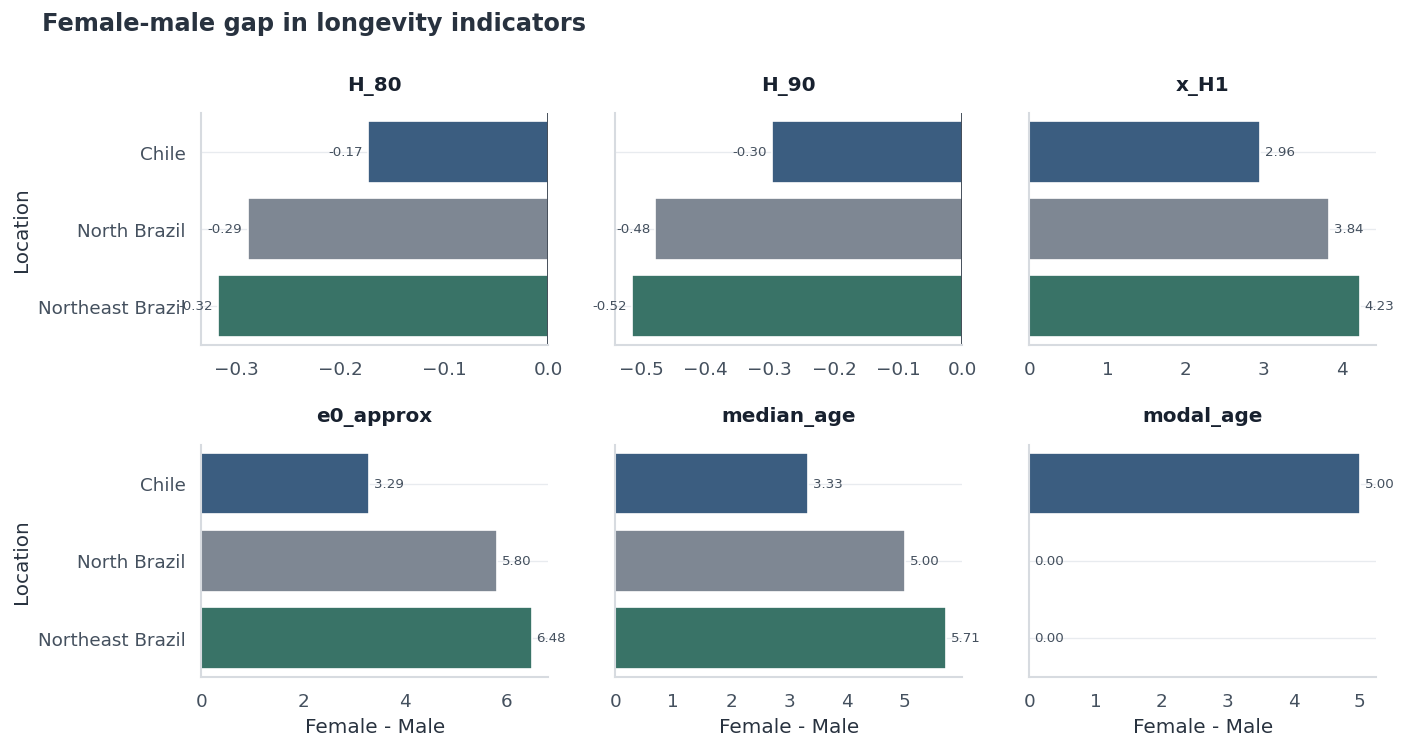

In [10]:
plot_conditional_survival(conditional_survival)
plot_sex_indicator_gaps(sex_gaps)


## Male mortality between ages 20, 40, and 60

This section focuses on men and compares Brazilian regions against Chile using conditional survival probabilities for 20-40, 40-60, and 20-60. The life table shows age-specific mortality differences, but cause-of-death data would be needed to attribute them to violent causes.


In [11]:
male_life_tables = life_tables[life_tables["country"].str.contains("Male")].copy()

male_20_60_survival = conditional_survival_probabilities(
    male_life_tables,
    transitions=((20, 40), (40, 60), (20, 60)),
)
male_20_60_survival.assign(
    conditional_survival_pct=lambda data: data["conditional_survival"] * 100
).pivot_table(
    index="country",
    columns="transition",
    values="conditional_survival_pct",
).round(2)


transition,20-40,20-60,40-60
country,,,
Chile - Male,97.59,90.47,92.70
North Brazil - Male,94.36,83.76,88.77
Northeast Brazil - Male,93.92,82.02,87.33


In [12]:
male_20_60_hazard = age_band_hazard_contributions(
    male_life_tables,
    bands=((20, 40), (40, 60), (20, 60)),
)
male_20_60_hazard.pivot_table(
    index="country",
    columns="age_band",
    values="hazard_increment",
).round(4)


age_band,20-40,20-60,40-60
country,,,
Chile - Male,0.0244,0.1002,0.0757
North Brazil - Male,0.0581,0.1772,0.1192
Northeast Brazil - Male,0.0627,0.1982,0.1355


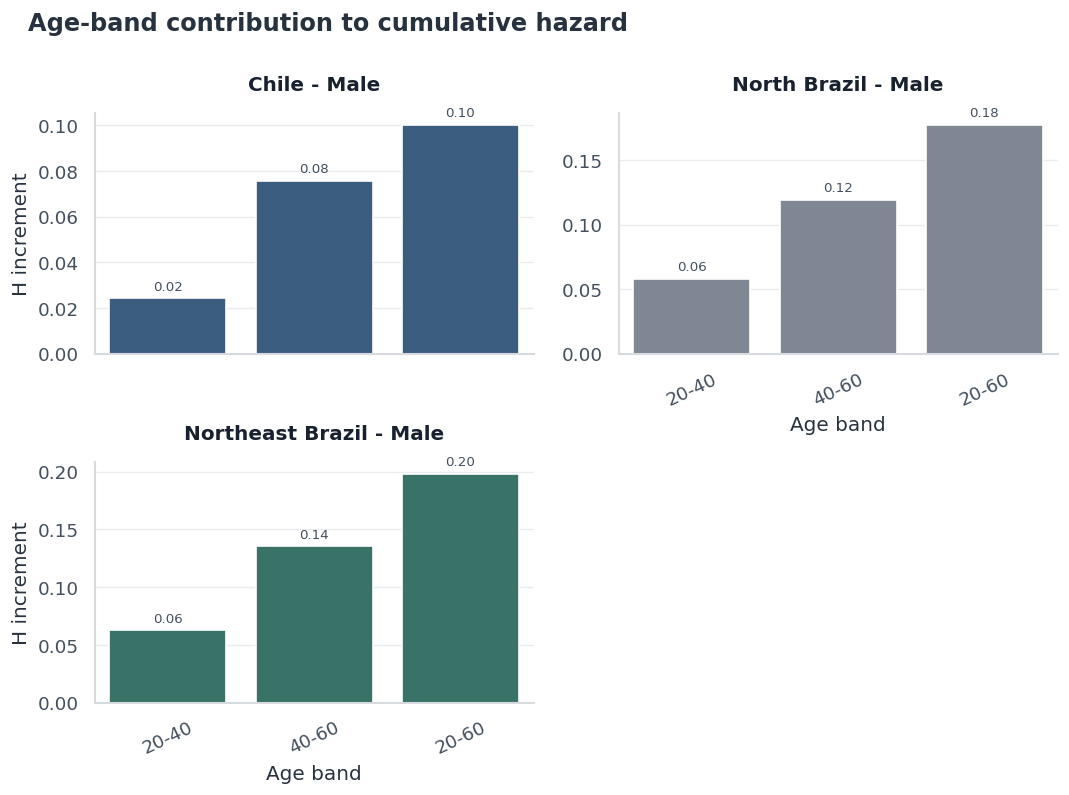

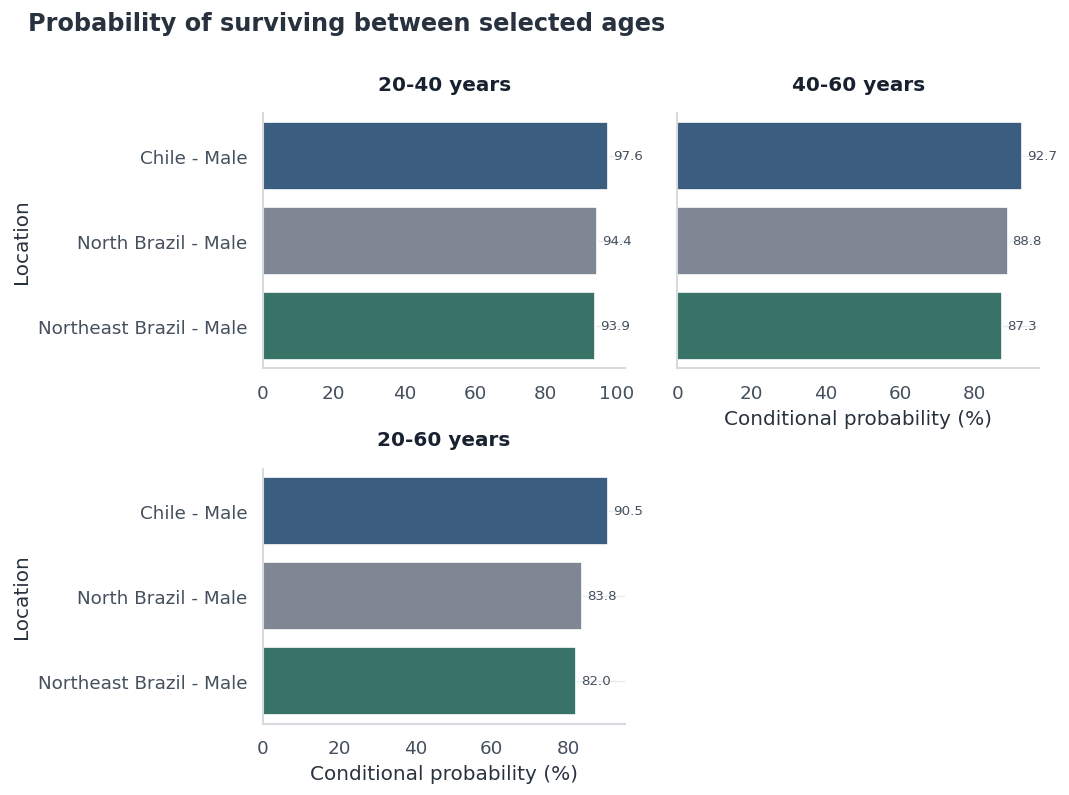

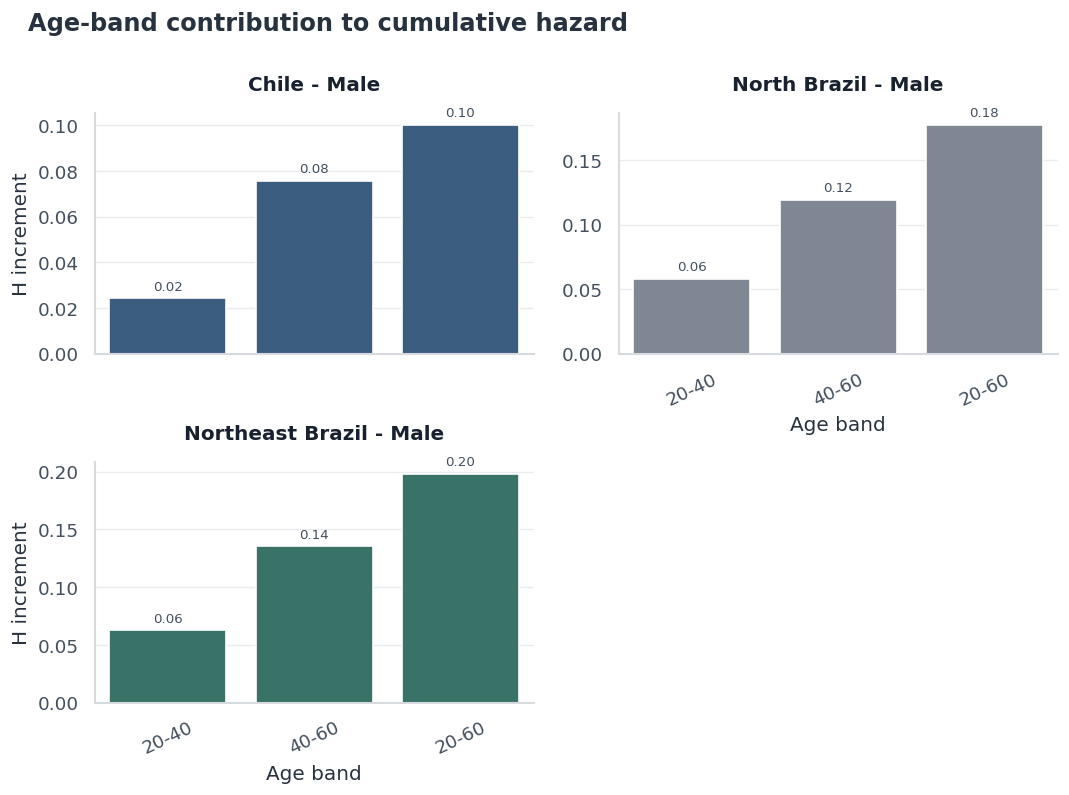

In [13]:
plot_conditional_survival(
    male_20_60_survival,
    output_path=PROJECT_ROOT / "outputs" / "figures" / "male_20_60_conditional_survival.png",
)
plot_age_band_hazard_contributions(
    male_20_60_hazard,
    output_path=PROJECT_ROOT / "outputs" / "figures" / "male_20_60_hazard_contributions.png",
)
